# Deep Learning HW1
##  Environment Setup

To ensure reproducibility, we recommend creating a dedicated conda environment before running this notebook.

### Step 1. Create a new conda environment

```bash
conda create -n dl_hw1 python=3.11 -y
conda activate dl_hw1
```
### Step 2. Install PyTorch

First try installing the GPU version:
```bash
python -m pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 --index-url https://download.pytorch.org/whl/cu121
python -m pip install torch-geometric==2.6.1
python -m pip install numpy matplotlib tqdm jupyter
```

The code below checks whether PyTorch has been installed correctly.
```bash
python -c "import sys; print(sys.executable)"
python -c "import torch; print(torch.__version__)"
python -c "import torch; print(torch.cuda.is_available())"
python -c "import torch_geometric; print(torch_geometric.__version__)"
python -c "import numpy; print(numpy.__version__)"
```

If Pytorch fails to detect the GPU, it is fine to install it using the CPU.
```bash
conda install pytorch torchvision torchaudio cpuonly -c pytorch -y
conda install numpy matplotlib tqdm jupyter
```


Environment Check
Run the following code cell to verify the environment.

In [1]:
import torch
import sys
import numpy as np

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
PyTorch: 2.5.0+cu121
NumPy: 2.3.5
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce MX450


## 0. Problem Setup and Data Preparation

In this section, we define the ordinary differential equation (ODE) considered in this assignment, its exact solution, and the default experimental setting.  
We also implement helper functions to generate training data and evaluation data.

- The random seed is fixed to `0` to ensure reproducibility.
- Training samples are generated by uniformly sampling `t` from `[0,1]`.
- The exact solution is used to construct the corresponding target values.

In [2]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import time

# ============================================================
# Basic Configurations
# - Set a fixed random seed for reproducibility
# - Device settings
# ============================================================
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ============================================================
# Problem Statement
# - ODE: du/dt = -a u, u(0)=1
# - exact solution: u(t) = exp(-a t)
# ============================================================
A_TRUE = 2.0
N_TRAIN_DEFAULT = 20
T_MIN, T_MAX = 0.0, 1.0
EPS = 1e-12

# =============================================================
# Default Experimental Settings
# ==============================================================
DEFAULT_CONFIG = {
    # Training data
    "train_size": 20,      # number of training data points
    # Neural Network architecture
    "hidden_dim": 32,      # hidden layer dimension
    "depth": 1,            # number of hidden layers
    "activation": "tanh",  # activation function
    # Optimization
    "optimizer": "Adam",   # optimizer
    "lr": 1e-3,            # learning rate 
    "n_iters": 5000,       # number of training iterations
    # Cross validation
    "k_fold": 1,           # number of folds for cross validation
    "seed": 0,             # random seed
}

device: cuda


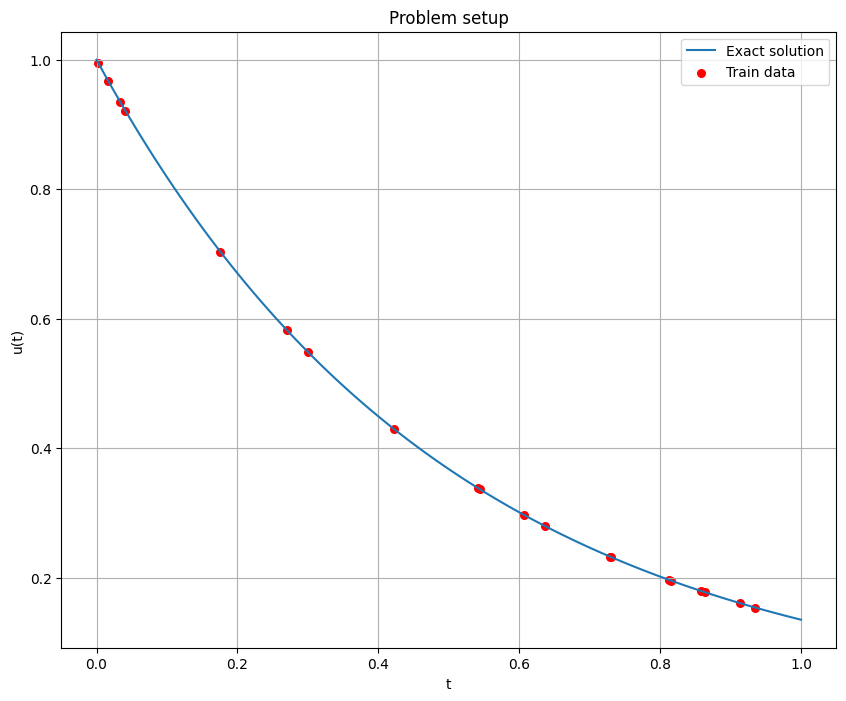

In [3]:
# ============================================================
# exact solution
# - Written to support both NumPy and Torch
# ============================================================
def exact_solution(t, a=A_TRUE):
    if isinstance(t, np.ndarray):
        return np.exp(-a * t)
    return torch.exp(-a * t)


# ============================================================
# Data generation function
# - Uniform sampling from the training data: [0,1]
# ============================================================
def generate_train_data(n_train=20, a=A_TRUE, t_min=T_MIN, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(t_min, t_max, size=(n_train, 1))
    t = np.sort(t, axis=0)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

def generate_eval_grid(n_eval, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

# ============================================================
# Quick visualization of the exact solution and the training data
# ============================================================
t_train, u_train = generate_train_data(n_train=N_TRAIN_DEFAULT, seed=0)
t_eval, u_eval = generate_eval_grid(n_eval = 100)

plt.figure(figsize=(10, 8))
plt.plot(t_eval.numpy(), u_eval.numpy(), label="Exact solution")
plt.scatter(t_train.numpy(), u_train.numpy(), color="red", s=30, label="Train data")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Problem setup")
plt.legend()
plt.grid(True)
plt.show()

## 1. Regression with Multi-Layer Perceptron (MLP)
### 0. Network and Training Utilities

In this section, we implement the core components required for the regression experiments.

These include:

- MLP model,
- optimizer builder,
- regression loss,
- relative \(L_2\) error,
- manual K-fold cross validation,
- training function.

All analyses (except K-fold cross validation) in later sections will reuse these functions.

In [4]:
# ============================================================
# MLP Model
# - depth = number of hidden layers
# - depth = 0 means a linear model without hidden layers
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, depth=1, out_dim=1, activation="tanh"):
        super().__init__()

        if activation == "tanh":
            act_layer = nn.Tanh
        elif activation == "relu":
            act_layer = nn.ReLU
        elif activation == "gelu":
            act_layer = nn.GELU
        elif activation == "sigmoid":
            act_layer = nn.Sigmoid
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        # ============================================================
        # TODO:
        # Build the neural network architecture.
        #
        # Requirements:
        # 1. If depth == 0, construct a linear model:
        #       Linear(in_dim -> out_dim)
        #
        # 2. If depth >= 1, construct an MLP with:
        #       - one input layer: Linear(in_dim -> hidden_dim)
        #       - 'depth' hidden layers in total
        #       - one output layer: Linear(hidden_dim -> out_dim)
        #       - the chosen activation function after each hidden layer
        #
        # Expected behavior:
        # - depth controls the number of hidden layers
        # - hidden_dim controls the width of each hidden layer
        # ============================================================
        layers = []

        if depth == 0:
            layers.append(nn.Linear(in_dim, out_dim))
        else:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(act_layer())

            for _ in range(depth - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(act_layer())

            layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [5]:
# ============================================================
# Optimizer
# - Build an optimizer from its name
# ============================================================
def build_optimizer(model, optimizer_name="Adam", lr=1e-3):
    # ============================================================
    # TODO:
    # Return the correct optimizer based on optimizer_name.
    #
    # Supported optimizers:
    # - "SGD"
    # - "Adam"
    # - "AdamW"
    #
    # Expected behavior:
    # - All optimizers should optimize model.parameters()
    # - The learning rate should be set by lr
    # ============================================================
    if optimizer_name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


In [6]:
# ============================================================
# Loss and metrics
# ============================================================
def regression_loss(model, t, u):
    # ============================================================
    # TODO:
    # Compute the Mean Squared Error (MSE) loss for regression.
    #
    # Steps:
    # 1. Compute the prediction u_pred = model(t)
    # 2. Compute the MSE loss:
    #       (1/N) * sum_i (u_pred_i - u_i)^2
    #
    # Expected behavior:
    # - The returned value should be a scalar tensor
    # - This loss will be used for backpropagation
    # ============================================================
    u_pred = model(t)
    mse = torch.mean((u_pred - u) ** 2)
    return mse
    
def relative_l2_error(u_pred, u_true, eps=EPS):
    # ============================================================
    # TODO:
    # Compute the relative L2 error:
    #
    #   ||u_pred - u_true||_2 / ||u_true||_2
    #
    # Requirements:
    # - Add eps to the denominator for numerical stability
    # ============================================================
    numerator = torch.sqrt(torch.sum((u_pred - u_true) ** 2))
    denominator = torch.sqrt(torch.sum(u_true ** 2)) + eps
    return (numerator / denominator).item()



In [7]:
# ============================================================
# Manual K-fold split
# - Build train/validation indices without external packages
# ============================================================
def build_kfold_indices(n_samples, k=5, shuffle=True, seed=0):
    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    # ============================================================
    # TODO:
    # Split the dataset indices into K folds manually.
    #
    # Steps:
    # 1. Compute the size of each fold
    # 2. For each fold:
    #    - use one part as validation indices
    #    - use the remaining parts as training indices
    # 3. Return a list of (train_idx, val_idx) pairs
    #
    # Expected behavior:
    # - The function should work even when n_samples is not divisible by k
    # - The first few folds may contain one extra sample
    # ============================================================
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1

    folds = []
    current = 0

    for fold_size in fold_sizes:
        start = current
        end = current + fold_size

        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        folds.append((train_idx, val_idx))
        current = end

    return folds

In [8]:
# ============================================================
# Results folder
# - Create a folder for each configuration under “results/regression”
# ============================================================
RESULT_ROOT = Path("results/regression")
RESULT_ROOT.mkdir(parents=True, exist_ok=True)


def make_run_name(config):
    # 설정을 문자열로 만들어 폴더 이름 생성
    return (
        f"h{config['hidden_dim']}_"
        f"d{config['depth']}_"
        f"act{config['activation']}_"
        f"opt{config['optimizer']}_"
        f"lr{config['lr']}_"
        f"k{config['k_fold']}_"
        f"n{config['train_size']}_"
        f"it{config['n_iters']}_"
        f"seed{config['seed']}"
    )

def train_single_run(config):
    # ============================================================
    # Prepare save paths
    # - Create a unique folder name from the configuration
    # - Save model parameters and result summary in that folder
    # ============================================================
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.pt"
    result_path = run_dir / "result.json"

    # Skip if the same configuration has already been trained
    if model_path.exists() and result_path.exists():
        print(f"[SKIP] Already trained: {run_name}")
        with open(result_path, "r", encoding="utf-8") as f:
            result = json.load(f)
        return result

    print(f"[TRAIN] Start: {run_name}")
    set_seed(config["seed"])

    # ============================================================
    # Generate full dataset
    # - Generate all training samples from the exact solution
    # ============================================================
    t_all, u_all = generate_train_data(
        n_train=config["train_size"],
        a=A_TRUE,
        seed=config["seed"]
    )

    # ============================================================
    # TODO 1:
    # Build K-fold splits.
    #
    # Requirements:
    # - If k_fold == 1, use the full dataset for both training and validation
    # - Otherwise, build train/validation index pairs using build_kfold_indices()
    #
    # Expected behavior:
    # - folds should be a list of (train_idx, val_idx) pairs
    # ============================================================
    if config["k_fold"] == 1:
        folds = [(np.arange(len(t_all)), np.arange(len(t_all)))]
    else:
        folds = build_kfold_indices(
            n_samples=len(t_all),
            k=config["k_fold"],
            shuffle=True,
            seed=config["seed"]
        )

    fold_results = []

    # ============================================================
    # Train one model for each fold
    # ============================================================
    for fold_id, (train_idx, val_idx) in enumerate(folds):

        # ========================================================
        # TODO 2:
        # Construct training and validation data for the current fold.
        #
        # Requirements:
        # - Use train_idx to select training samples
        # - Use val_idx to select validation samples
        # - Move all tensors to device
        # ========================================================
        t_train = t_all[train_idx].to(device)
        u_train = u_all[train_idx].to(device)
        t_val = t_all[val_idx].to(device)
        u_val = u_all[val_idx].to(device)

        # ========================================================
        # TODO 3:
        # Initialize the model, optimizer, and history dictionary.
        #
        # Requirements:
        # - Build an MLP using the current config
        # - Build the optimizer using build_optimizer()
        # - Prepare history to store:
        #   iteration, train_loss, val_loss, val_rel_l2, elapsed_time
        # ========================================================
        model = MLP(
            hidden_dim=config["hidden_dim"],
            depth=config["depth"],
            activation=config["activation"]
        ).to(device)

        optimizer = build_optimizer(
            model,
            optimizer_name=config["optimizer"],
            lr=config["lr"]
        )

        history = {
            "iter": [],
            "train_loss": [],
            "val_loss": [],
            "val_rel_l2": [],
            "elapsed_time": [],
        }

        start_time = time.time()
        log_every = max(1, config["n_iters"] // 10)

        # ========================================================
        # Training loop for the current fold
        # ========================================================
        for it in range(1, config["n_iters"] + 1):

            # ====================================================
            # TODO 4:
            # Perform one training step.
            #
            # Steps:
            # 1. Set model to train mode
            # 2. Clear previous gradients
            # 3. Compute training loss
            # 4. Run backpropagation
            # 5. Update parameters
            # ====================================================
            model.train()
            optimizer.zero_grad()

            loss = regression_loss(model, t_train, u_train)
            loss.backward()
            optimizer.step()

            # ====================================================
            # TODO 5:
            # Perform one validation step.
            #
            # Steps:
            # 1. Set model to evaluation mode
            # 2. Disable gradient computation
            # 3. Predict on the validation set
            # 4. Compute validation MSE loss
            # 5. Compute validation relative L2 error
            # ====================================================
            model.eval()
            with torch.no_grad():
                u_val_pred = model(t_val)
                val_loss = torch.mean((u_val_pred - u_val) ** 2)
                val_rel_l2 = relative_l2_error(u_val_pred, u_val)


            elapsed = time.time() - start_time

            # ====================================================
            # The following code records the training loss, validation loss, validation relative error, and elapsed time for each iteration number.
            # ====================================================
            history["iter"].append(it)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss.item())
            history["val_rel_l2"].append(val_rel_l2)
            history["elapsed_time"].append(elapsed)

            if (it % log_every == 0) or (it == config["n_iters"]):
                print(
                    f"[Fold {fold_id+1}/{len(folds)}] "
                    f"[{it}/{config['n_iters']}] "
                    f"Train loss: {loss.item():.6e}, "
                    f"Validation loss: {val_loss.item():.6e}, "
                    f"Validation Rel L2: {val_rel_l2:.6e}, "
                    f"Training time: {elapsed:.2f}s"
                )

        # ========================================================
        # This is a summary of the current fold, including the fold_id, the validation relative L2 error, and the history recorded at each specific iteration.
        # ========================================================
        fold_result = {
            "fold_id": int(fold_id),
            "val_rel_l2": float(history["val_rel_l2"][-1]),
            "history": history
        }
        fold_results.append(fold_result)

    # ============================================================
    # Save the final trained model and summarize all fold results.
    # ============================================================
    torch.save(model.state_dict(), model_path)

    result = {
        "config": config,
        "fold_results": fold_results,
        "mean_val_rel_l2": float(np.mean([fr["val_rel_l2"] for fr in fold_results])),
        "std_val_rel_l2": float(np.std([fr["val_rel_l2"] for fr in fold_results]))
    }

    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"[DONE] Saved to: {run_dir}")
    return result

### 0.1 Basic Training Run

In this section, we run a single training experiment using the default setting and check whether the full pipeline works correctly.
This step helps verify that the model, loss, optimizer, and saving procedure are implemented properly before running larger analyses.

In [9]:
# ============================================================
# Default run
# ============================================================
default_result = train_single_run(DEFAULT_CONFIG)
print(default_result["mean_val_rel_l2"], default_result["std_val_rel_l2"])

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
0.003443556372076273 0.0


In [10]:
# ============================================================
# Example: compare K values
# ============================================================
k_list = [1, 5, N_TRAIN_DEFAULT]  # K=1, K=5, LOOCV

k_results = []
for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k
    result = train_single_run(config)
    k_results.append(result)

for result in k_results:
    print(
        f"K={result['config']['k_fold']}, "
        f"mean_rel_l2={result['mean_val_rel_l2']:.6e}, "
        f"std_rel_l2={result['std_val_rel_l2']:.6e}"
    )

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k20_n20_it5000_seed0
K=1, mean_rel_l2=3.443556e-03, std_rel_l2=0.000000e+00
K=5, mean_rel_l2=6.278952e-03, std_rel_l2=2.152727e-03
K=20, mean_rel_l2=7.323046e-03, std_rel_l2=8.732820e-03


### 1.1 Analysis Questions

In this section, we define reusable functions for loading saved results, evaluating trained models on a uniform grid, and visualizing the outputs.

These helper functions will be used in the following analyses:

- optimizer analysis,
- learning rate analysis,
- network width analysis,
- network depth analysis,
- activation function analysis,
- training data size analysis,
- and K-fold cross validation analysis.

#### 1.1.1 Hyperparameter Analysis

In [11]:
# ============================================================
# Example: run multiple settings automatically
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
lr_list = [1e-2, 1e-3, 1e-4]
hidden_dims = [4, 16, 32]
depths = [0, 1, 2]
activations = ["tanh", "relu", "sigmoid"]
train_data = [5, 10, 20, 50, 100]
k_list = [1, 5, N_TRAIN_DEFAULT]  # K=1, K=5, LOOCV

all_results = []

# optimizer sweep
for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name
    result = train_single_run(config)
    all_results.append(result)

# learning rate sweep
for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr
    result = train_single_run(config)
    all_results.append(result)

# hidden width sweep
for h in hidden_dims:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h
    result = train_single_run(config)
    all_results.append(result)

# depth sweep
for d in depths:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d
    result = train_single_run(config)
    all_results.append(result)

# activation sweep
for act in activations:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act
    result = train_single_run(config)
    all_results.append(result)

# training data size sweep
for n in train_data:
    config = DEFAULT_CONFIG.copy()
    config["train_size"] = n
    result = train_single_run(config)
    all_results.append(result)

[SKIP] Already trained: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdamW_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.01_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.0001_k1_n20_it5000_seed0
[SKIP] Already trained: h4_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h16_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d0_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d2_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h3

Compare the training dynamics and prediction accuracy under different hyperparameter settings.

For each analysis, we visualize:

- the training loss curve,
- the prediction together with the exact solution,
- the pointwise relative error,
- and the relative $L_2$ error.

When plotting a graph, you can use the function provided below or create your own.

In [12]:
# ============================================================
# Load Result
# ============================================================
def load_result(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model


# ============================================================
# Create evaluation data
# - Use uniform grid in the domain [0,1]
# ============================================================
def generate_analysis_grid(n_eval=200, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    u_tensor = torch.tensor(u, dtype=torch.float32).to(device)
    return t_tensor, u_tensor


# ============================================================
#  Model Prediction and Error Calculation
# ============================================================
def pointwise_relative_error(u_pred, u_true, eps=1e-12):
    return torch.abs(u_pred - u_true) / (torch.abs(u_true) + eps)

def evaluate_model_on_grid(model, n_eval=200):
    t_grid, u_exact = generate_analysis_grid(n_eval=n_eval)

    with torch.no_grad():
        u_pred = model(t_grid)

    rel_l2 = relative_l2_error(u_pred, u_exact)
    pw_rel = pointwise_relative_error(u_pred, u_exact).detach().cpu().numpy()

    return {
        "t": t_grid.detach().cpu().numpy(),
        "u_exact": u_exact.detach().cpu().numpy(),
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

# ============================================================
# 공통 plot style
# ============================================================
DEFAULT_LINEWIDTH = 2.0
DEFAULT_ALPHA = 0.75
EXACT_LINEWIDTH = 3.0
EXACT_ALPHA = 0.9


# ============================================================
# Training loss plot
# ============================================================
def plot_training_loss_comparison(results_dict, title="Training Loss Comparison"):
    plt.figure(figsize=(7, 4))

    for label, result in results_dict.items():
        history = result["fold_results"][0]["history"]
        plt.plot(
            history["iter"],
            history["train_loss"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Training Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Prediction vs exact plot
# ============================================================
def plot_prediction_vs_exact(eval_dict, title="Prediction vs Exact"):
    plt.figure(figsize=(7, 4))

    # exact solution 먼저 그림
    first_key = list(eval_dict.keys())[0]
    plt.plot(
        eval_dict[first_key]["t"],
        eval_dict[first_key]["u_exact"],
        label="Exact",
        linewidth=EXACT_LINEWIDTH,
        alpha=EXACT_ALPHA,
        color="black"
    )

    # 각 설정별 prediction
    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["u_pred"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Pointwise relative error plot
# ============================================================
def plot_pointwise_relative_error(eval_dict, title="Pointwise Relative Error"):
    plt.figure(figsize=(7, 4))

    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["pointwise_rel_error"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("Pointwise Relative Error")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Relative L2 bar plot
# ============================================================
def plot_relative_l2_bar(eval_dict, title="Relative L2 Error"):
    labels = list(eval_dict.keys())
    values = [eval_dict[label]["relative_l2"] for label in labels]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, alpha=0.8)
    plt.ylabel("Relative L2 Error")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.show()


# ============================================================
# Relative L2 value print
# ============================================================
def print_relative_l2_table(eval_dict):
    print(f"{'Setting':<20} {'Relative L2 Error':<20}")
    print("-" * 40)
    for label, out in eval_dict.items():
        print(f"{label:<20} {out['relative_l2']:<20.6e}")

#### 1.1.1(a) Optimizer analysis

[SKIP] Already trained: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdamW_lr0.001_k1_n20_it5000_seed0


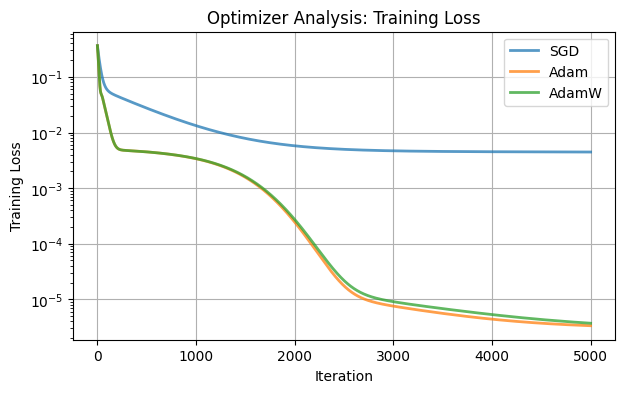

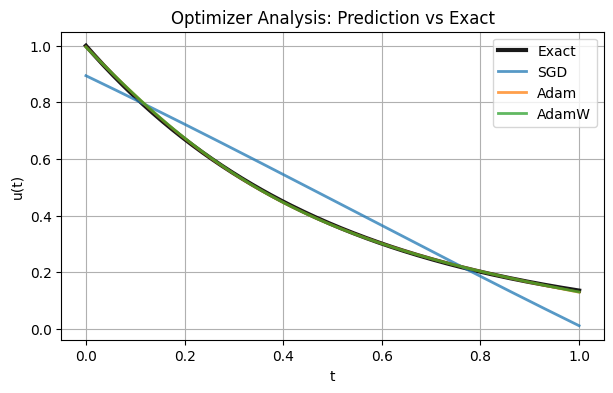

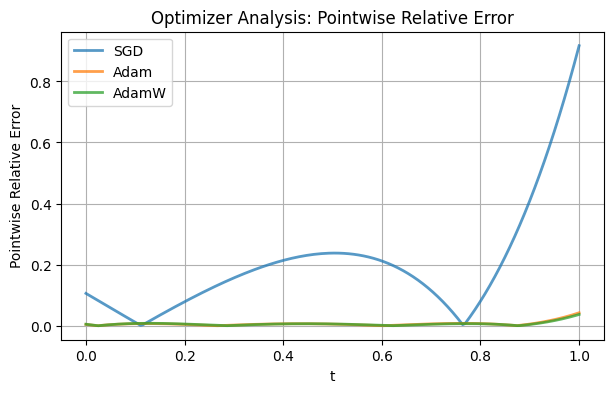

Setting              Relative L2 Error   
----------------------------------------
SGD                  1.385799e-01        
Adam                 5.291078e-03        
AdamW                5.495455e-03        


In [13]:
# ============================================================
# Optimizer Analysis
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
optimizer_results = {}
optimizer_eval = {}

for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    optimizer_results[opt_name] = loaded_result
    optimizer_eval[opt_name] = eval_out

plot_training_loss_comparison(optimizer_results,title="Optimizer Analysis: Training Loss")
plot_prediction_vs_exact(optimizer_eval,title="Optimizer Analysis: Prediction vs Exact")
plot_pointwise_relative_error(optimizer_eval,title="Optimizer Analysis: Pointwise Relative Error")

print_relative_l2_table(optimizer_eval)

#### 1.1.1(b) Learning Rate Analysis

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.01_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.0001_k1_n20_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


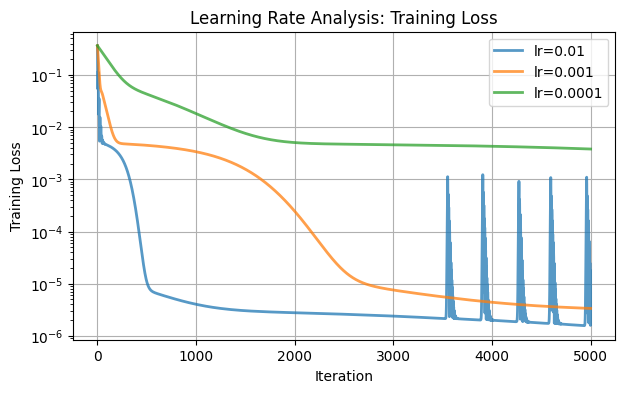

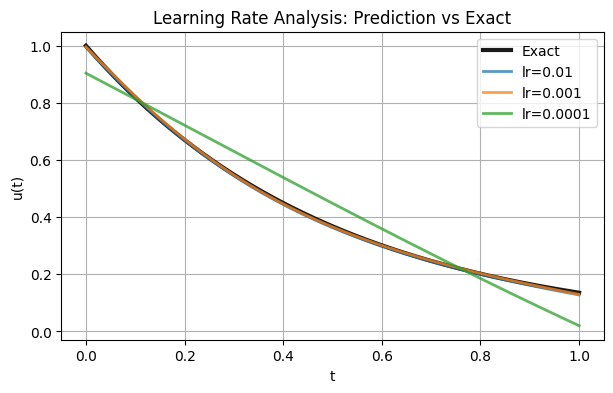

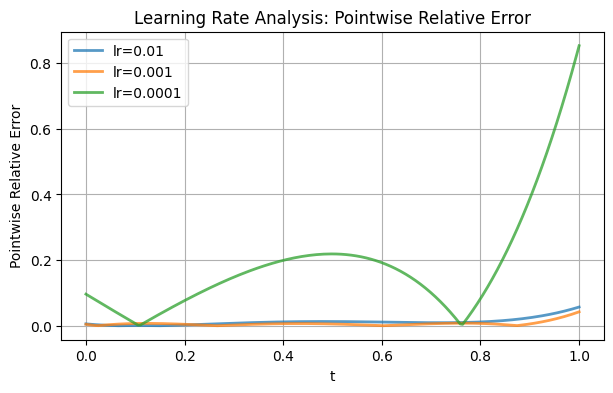

Setting              Relative L2 Error   
----------------------------------------
lr=0.01              7.505275e-03        
lr=0.001             5.291078e-03        
lr=0.0001            1.289164e-01        


In [14]:
# ============================================================
# Learning Rate Analysis
# ============================================================
lr_list = [1e-2, 1e-3, 1e-4]

lr_results = {}
lr_eval = {}

for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"lr={lr}"
    lr_results[label] = loaded_result
    lr_eval[label] = eval_out

plot_training_loss_comparison(
    lr_results,
    title="Learning Rate Analysis: Training Loss"
)

plot_prediction_vs_exact(
    lr_eval,
    title="Learning Rate Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    lr_eval,
    title="Learning Rate Analysis: Pointwise Relative Error"
)

print_relative_l2_table(lr_eval)

#### 1.1.1(c) Network Architecture Analysis - hidden dimension

[SKIP] Already trained: h4_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h16_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h64_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


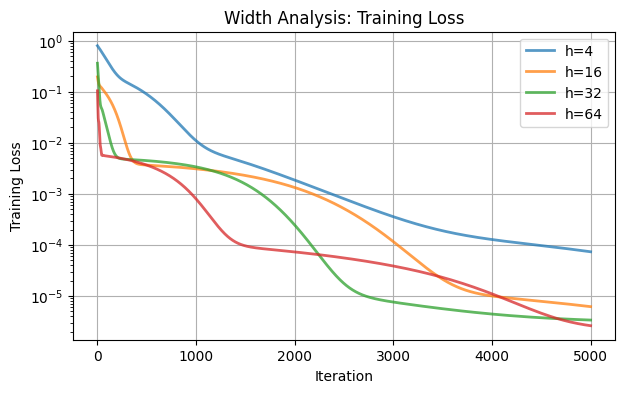

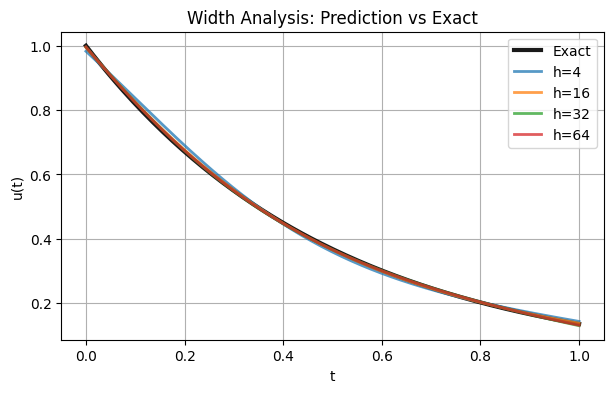

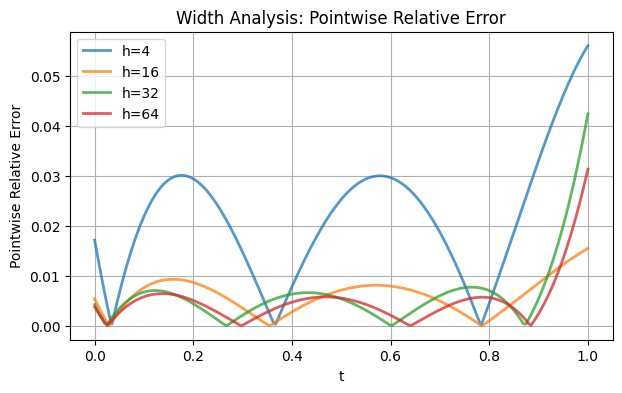

Setting              Relative L2 Error   
----------------------------------------
h=4                  2.057499e-02        
h=16                 6.264656e-03        
h=32                 5.291078e-03        
h=64                 4.559063e-03        


In [15]:
width_list = [4, 16, 32, 64]
width_results = {}
width_eval = {}

for h in width_list:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"h={h}"
    width_results[label] = loaded_result
    width_eval[label] = eval_out

plot_training_loss_comparison(
    width_results,
    title="Width Analysis: Training Loss"
)

plot_prediction_vs_exact(
    width_eval,
    title="Width Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    width_eval,
    title="Width Analysis: Pointwise Relative Error"
)

print_relative_l2_table(width_eval)

#### 1.1.1(c) Network Architecture Analysis - network depth

[SKIP] Already trained: h32_d0_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d2_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d3_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d4_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


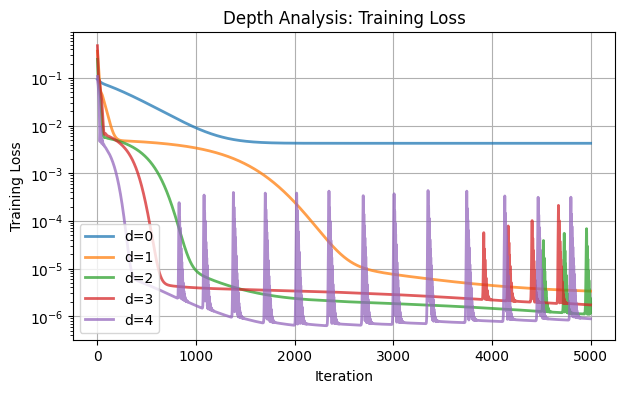

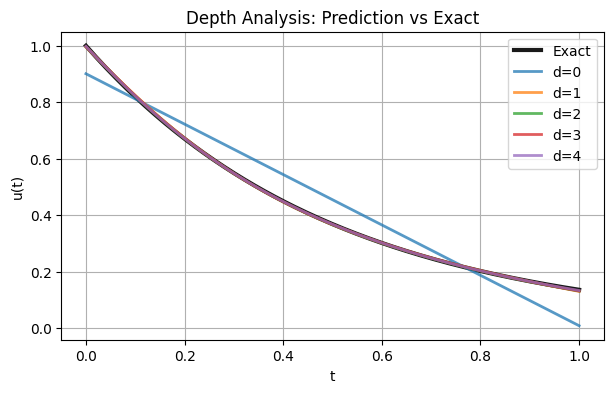

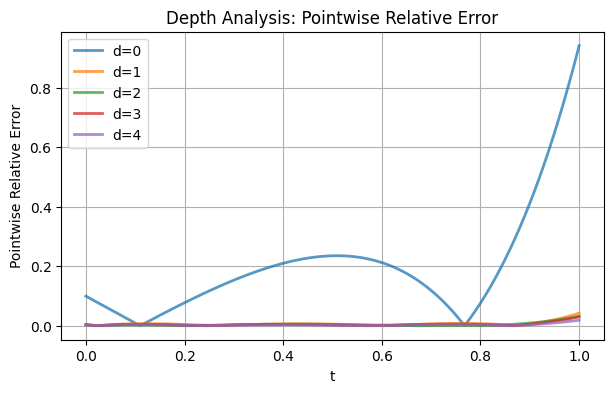

Setting              Relative L2 Error   
----------------------------------------
d=0                  1.370402e-01        
d=1                  5.291078e-03        
d=2                  3.319294e-03        
d=3                  3.654410e-03        
d=4                  2.605650e-03        


In [16]:
depth_list = [0, 1, 2, 3, 4]

depth_results = {}
depth_eval = {}

for d in depth_list:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"d={d}"
    depth_results[label] = loaded_result
    depth_eval[label] = eval_out

plot_training_loss_comparison(
    depth_results,
    title="Depth Analysis: Training Loss"
)

plot_prediction_vs_exact(
    depth_eval,
    title="Depth Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    depth_eval,
    title="Depth Analysis: Pointwise Relative Error"
)

print_relative_l2_table(depth_eval)

#### 1.1.1(c) Network Architecture Analysis -Activation function

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actrelu_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actsigmoid_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


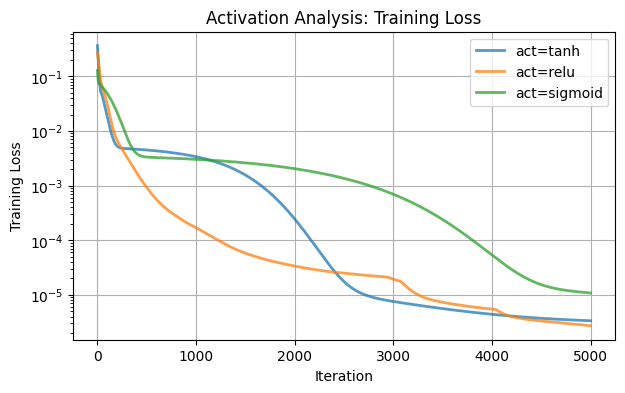

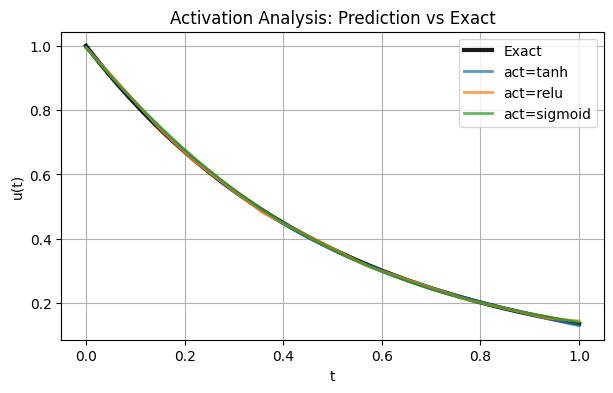

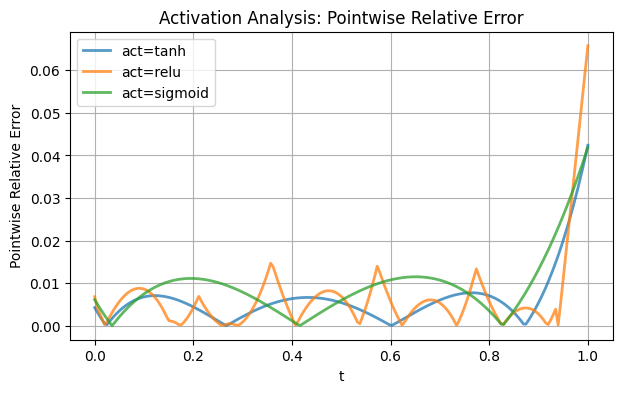

Setting              Relative L2 Error   
----------------------------------------
act=tanh             5.291078e-03        
act=relu             6.307790e-03        
act=sigmoid          7.919478e-03        


In [17]:
activation_list = ["tanh", "relu", "sigmoid"]

act_results = {}
act_eval = {}

for act in activation_list:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"act={act}"
    act_results[label] = loaded_result
    act_eval[label] = eval_out

plot_training_loss_comparison(
    act_results,
    title="Activation Analysis: Training Loss"
)

plot_prediction_vs_exact(
    act_eval,
    title="Activation Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    act_eval,
    title="Activation Analysis: Pointwise Relative Error"
)

print_relative_l2_table(act_eval)

#### 1.1.1(d) Training Data Analysis

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n5_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n10_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n50_it5000_seed0


/tmp/ipykernel_712/3656981953.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


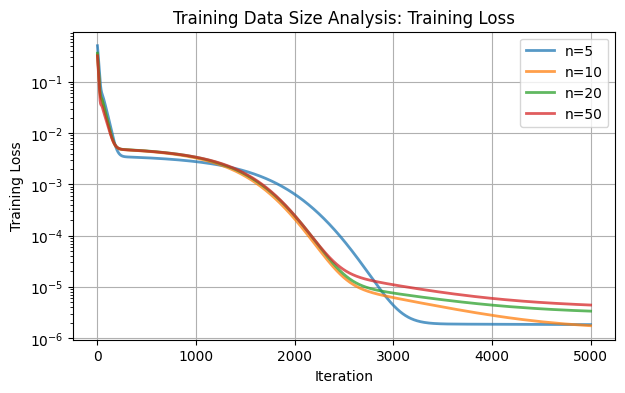

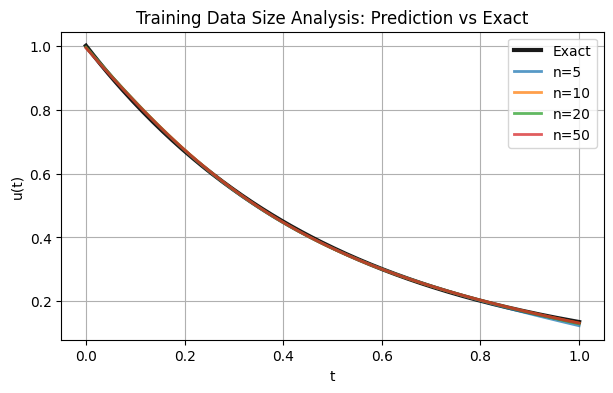

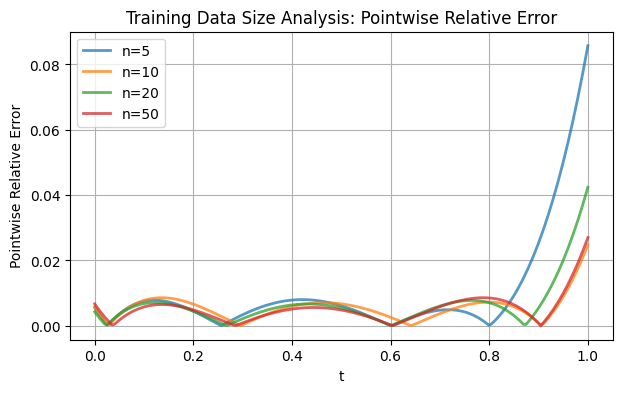

Setting              Relative L2 Error   
----------------------------------------
n=5                  7.517468e-03        
n=10                 5.703559e-03        
n=20                 5.291078e-03        
n=50                 4.671998e-03        


In [18]:
train_data = [5, 10, 20, 50]

data_results = {}
data_eval = {}

for n in train_data:
    config = DEFAULT_CONFIG.copy()
    config["train_size"] = n

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"n={n}"
    data_results[label] = loaded_result
    data_eval[label] = eval_out

plot_training_loss_comparison(
    data_results,
    title="Training Data Size Analysis: Training Loss"
)

plot_prediction_vs_exact(
    data_eval,
    title="Training Data Size Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    data_eval,
    title="Training Data Size Analysis: Pointwise Relative Error"
)

print_relative_l2_table(data_eval)


#### 1.1.2 K-fold Cross Validation

In this section, we compare three validation settings:

- K = 1,
- K = 5,
- Leave-One-Out Cross Validation (LOOCV).

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k20_n20_it5000_seed0


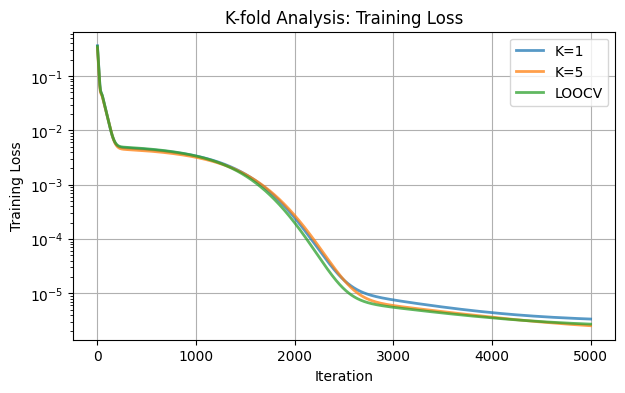

Setting              Mean Rel L2          Std Rel L2          
------------------------------------------------------------
K=1                  3.443556e-03         0.000000e+00        
K=5                  6.278952e-03         2.152727e-03        
LOOCV                7.323046e-03         8.732820e-03        


In [19]:
k_list = [1, 5, DEFAULT_CONFIG["train_size"]]   # K=1, K=5, LOOCV

cv_results = {}

for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k

    result = train_single_run(config)
    label = "LOOCV" if k == DEFAULT_CONFIG["train_size"] else f"K={k}"
    cv_results[label] = result



# training loss comparison
plot_training_loss_comparison(
    cv_results,
    title="K-fold Analysis: Training Loss"
)

# relative L2 comparison
labels = list(cv_results.keys())
values = [cv_results[label]["mean_val_rel_l2"] for label in labels]

print(f"{'Setting':<20} {'Mean Rel L2':<20} {'Std Rel L2':<20}")
print("-" * 60)
for label, result in cv_results.items():
    print(
        f"{label:<20} "
        f"{result['mean_val_rel_l2']:<20.6e} "
        f"{result['std_val_rel_l2']:<20.6e}"
    )

## 2. Physics-Informed Neural Networks (PINNs)

In this section, we extend the regression model to a Physics-Informed Neural Network (PINN). Unlike standard regression, PINN incorporates the governing differential equation into the training objective. The same MLP architecture is reused, but the loss function is modified to include a physics residual term and an initial condition term.

### 1. Automatic Differentiation (Background)

### Why do we need automatic differentiation in PINNs?

In a Physics-Informed Neural Network, the loss function includes the differential equation residual.
For this reason, we must compute derivatives of the neural network output with respect to the input variable.
PyTorch provides this functionality through `torch.autograd.grad`, which allows us to compute these derivatives automatically as part of the computational graph.

The code below compares the results obtained using Autograd with those obtained using a numerical differentiation method (finite differences) for the derivative of u(t) = exp(-at).

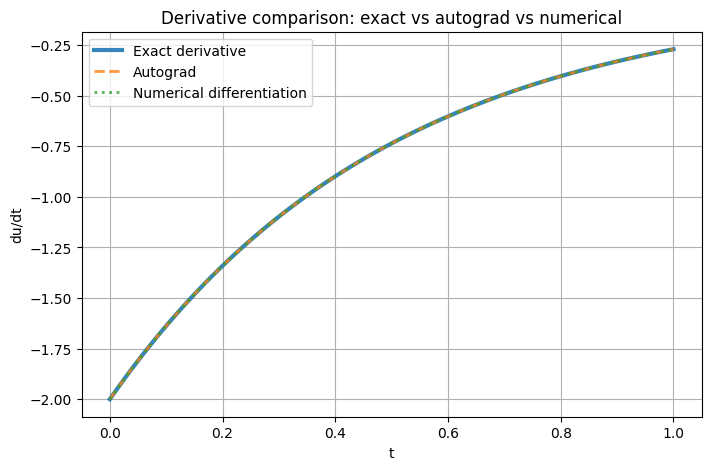

Relative L2 error (autograd): 0.0
Relative L2 error (numerical differentiation): 0.00013087104889564216


In [20]:
# exact function
A_TRUE = 2.0

def exact_solution_torch(t, a=A_TRUE):
    return torch.exp(-a * t)

# test points
t = torch.linspace(0, 1, 100).reshape(-1, 1)
t_autograd = t.clone().detach().requires_grad_(True)

# ------------------------------------------------------------
# 1. Automatic differentiation
# ------------------------------------------------------------
u_autograd = exact_solution_torch(t_autograd)
du_dt_autograd = torch.autograd.grad(
    outputs=u_autograd,                        # function output
    inputs=t_autograd,                         # variable to differentiate with respect to
    grad_outputs=torch.ones_like(u_autograd),  # same shape as outputs
    create_graph=True                          # keep graph for higher-order derivatives if needed
)[0]

# ------------------------------------------------------------
# 2. Numerical differentiation (finite difference)
# ------------------------------------------------------------
h = 1e-4
t_plus = t + h
t_minus = t - h

u_plus = exact_solution_torch(t_plus)
u_minus = exact_solution_torch(t_minus)

du_dt_numeric = (u_plus - u_minus) / (2 * h)

# ------------------------------------------------------------
# 3. Exact derivative
# ------------------------------------------------------------
du_dt_exact = -A_TRUE * exact_solution_torch(t)

# ------------------------------------------------------------
# 4. Compare
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(t.numpy(), du_dt_exact.numpy(), label="Exact derivative", linewidth=3, alpha=0.9)
plt.plot(t.numpy(), du_dt_autograd.detach().numpy(), "--", label="Autograd", linewidth=2, alpha=0.8)
plt.plot(t.numpy(), du_dt_numeric.numpy(), ":", label="Numerical differentiation", linewidth=2, alpha=0.8)
plt.xlabel("t")
plt.ylabel("du/dt")
plt.title("Derivative comparison: exact vs autograd vs numerical")
plt.legend()
plt.grid(True)
plt.show()

# relative errors
rel_err_autograd = torch.sqrt(torch.sum((du_dt_autograd - du_dt_exact)**2)) / torch.sqrt(torch.sum(du_dt_exact**2))
rel_err_numeric = torch.sqrt(torch.sum((du_dt_numeric - du_dt_exact)**2)) / torch.sqrt(torch.sum(du_dt_exact**2))

print("Relative L2 error (autograd):", rel_err_autograd.item())
print("Relative L2 error (numerical differentiation):", rel_err_numeric.item())

### 2. PINN Training Utilities

An explanation of PINN is provided in the PDF file. Below are the settings for the default configuration.

In [21]:
# ============================================================
# PINN setting
# ============================================================
PINN_DEFAULT_CONFIG = {
    "hidden_dim": 32,
    "depth": 1,
    "activation": "tanh",
    "optimizer": "Adam",
    "lr": 1e-3,
    "train_size": 0,          # number of observed data points
    "n_collocation": 100,     # number of collocation points
    "n_iters": 5000,
    "seed": 0,
}

### (a). Collocation data points 
We implement the core components required for the forward PINN. These include collocation point generation, automatic differentiation for computing derivatives, the PINN loss function, and the training function.

In [22]:
# ============================================================
# Collocation points
# - collocation points are sampled from [0,1]
# - no exact solution values are needed at these points
# ============================================================
def generate_collocation_points(n_collocation=100, t_min=T_MIN, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(t_min, t_max, size=(n_collocation, 1))
    t = np.sort(t, axis=0)
    return torch.tensor(t, dtype=torch.float32)

### (b). Setting of AutoGrad

In [23]:
# ============================================================
# Automatic differentiation helper
# - compute du/dt using torch.autograd.grad
# ============================================================
def compute_du_dt(model, t):
    # ============================================================
    # TODO:
    # Compute the derivative du/dt using automatic differentiation.
    #
    # Steps:
    # 1. Set t to require gradients
    # 2. Compute u_hat = model(t)
    # 3. Use torch.autograd.grad to compute du_dt
    #
    # Expected behavior:
    # - return both u_hat and du_dt
    # - du_dt should have the same shape as t
    # ============================================================
    t = t.clone().detach().to(device).requires_grad_(True)
    u_hat = model(t)
    du_dt = torch.autograd.grad(
        outputs=u_hat,
        inputs=t,
        grad_outputs=torch.ones_like(u_hat),
        create_graph=True
    )[0]
    return u_hat, du_dt

### (c) Setting of Training loss

In [24]:
# ============================================================
# PINN loss
# - total loss = physics loss + data loss + initial condition loss
# ============================================================
def pinn_loss(model, t_collocation, t_data=None, u_data=None, a=A_TRUE):
    # ============================================================
    # TODO:
    # Implement the PINN loss.
    #
    # Components:
    # 1. Physics loss:
    #       mean(du/dt + a*u)^2
    # 2. Data loss (only if data are provided):
    #       mean((u_hat - u_data)^2)
    # 3. Initial condition loss:
    #       (u_hat(0) - 1)^2
    #
    # Expected behavior:
    # - If no data are provided, use only physics loss + IC loss
    # - Return:
    #     total_loss, physics_loss, data_loss, ic_loss
    # ============================================================
    # physics loss
    u_col, du_dt = compute_du_dt(model, t_collocation)
    residual = du_dt + a * u_col
    physics_loss = torch.mean(residual ** 2)

    # data loss
    if (t_data is not None) and (u_data is not None) and (len(t_data) > 0):
        t_data = t_data.to(device)
        u_data = u_data.to(device)
        u_pred_data = model(t_data)
        data_loss = torch.mean((u_pred_data - u_data) ** 2)
    else:
        data_loss = torch.tensor(0.0, dtype=torch.float32, device=device)

    # initial condition loss
    t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device)
    u0_pred = model(t0)
    ic_loss = torch.mean((u0_pred - 1.0) ** 2)

    total_loss = physics_loss + data_loss + ic_loss
    return total_loss, physics_loss, data_loss, ic_loss

In [25]:
# ============================================================
# Result directory for PINN
# ============================================================
PINN_RESULT_ROOT = Path("results/pinn")
PINN_RESULT_ROOT.mkdir(parents=True, exist_ok=True)

def make_pinn_run_name(config):
    return (
        f"h{config['hidden_dim']}_"
        f"d{config['depth']}_"
        f"act{config['activation']}_"
        f"opt{config['optimizer']}_"
        f"lr{config['lr']}_"
        f"ndata{config['train_size']}_"
        f"ncol{config['n_collocation']}_"
        f"it{config['n_iters']}_"
        f"seed{config['seed']}"
    )

This function trains a forward PINN for one configuration. It saves the trained parameters and the recorded loss history. If the same setting has already been trained, the function loads the saved result and skips retraining.

In [26]:
def train_single_pinn_run(config):
    # ============================================================
    # Prepare save paths
    # - Create a unique folder name from the configuration
    # - Save model parameters and result summary in that folder
    # ============================================================
    run_name = make_pinn_run_name(config)
    run_dir = PINN_RESULT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.pt"
    result_path = run_dir / "result.json"

    # Skip if the same configuration has already been trained
    if model_path.exists() and result_path.exists():
        print(f"[SKIP] Already trained: {run_name}")
        with open(result_path, "r", encoding="utf-8") as f:
            result = json.load(f)
        return result

    print(f"[TRAIN] Start: {run_name}")
    set_seed(config["seed"])

    # ============================================================
    # TODO 1:
    # Prepare observed data for PINN training.
    #
    # Requirements:
    # - If train_size > 0, generate observed data (t_data, u_data)
    #   using generate_train_data()
    # - If train_size == 0, set t_data and u_data to None
    #
    # Expected behavior:
    # - PINN should be able to train with or without observed data
    # ============================================================
    if config["train_size"] > 0:
        t_data, u_data = generate_train_data(
            n_train=config["train_size"],
            a=A_TRUE,
            seed=config["seed"]
        )
    else:
        t_data, u_data = None, None

    # ============================================================
    # TODO 2:
    # Generate collocation points.
    #
    # Requirements:
    # - Use generate_collocation_points()
    # - Move the collocation tensor to device
    #
    # Expected behavior:
    # - Collocation points are used to enforce the differential equation
    # ============================================================
    t_collocation = generate_collocation_points(
        n_collocation=config["n_collocation"],
        seed=config["seed"]
    ).to(device)

    # ============================================================
    # TODO 3:
    # Initialize the model and optimizer.
    #
    # Requirements:
    # - Build an MLP with the current PINN configuration
    # - Build the optimizer using build_optimizer()
    #
    # Expected behavior:
    # - The same MLP architecture as regression should be reused here
    # ============================================================
    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)

    optimizer = build_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"]
    )

    history = {
        "iter": [],
        "train_loss": [],
        "physics_loss": [],
        "data_loss": [],
        "ic_loss": [],
        "elapsed_time": [],
    }

    start_time = time.time()
    log_every = max(1, config["n_iters"] // 10)

    # ============================================================
    # PINN training loop
    # ============================================================
    for it in range(1, config["n_iters"] + 1):

        # ========================================================
        # TODO 4:
        # Perform one training step for PINN.
        #
        # Steps:
        # 1. Set the model to train mode
        # 2. Clear previous gradients
        # 3. Compute the total PINN loss and each component
        #    using pinn_loss()
        # 4. Run backpropagation
        # 5. Update the model parameters
        #
        # Expected behavior:
        # - total_loss should include physics, data, and IC terms
        # ========================================================
        model.train()
        optimizer.zero_grad()

        total_loss, physics_loss, data_loss, ic_loss = pinn_loss(
            model=model,
            t_collocation=t_collocation,
            t_data=t_data,
            u_data=u_data,
            a=A_TRUE
        )

        total_loss.backward()
        optimizer.step()

        elapsed = time.time() - start_time

        # ====================================================
        # The following code records the training loss, physics loss, data loss, initial condition loss and elapsed time for each iteration number.
        # ====================================================
        history["iter"].append(it)
        history["train_loss"].append(total_loss.item())
        history["physics_loss"].append(physics_loss.item())
        history["data_loss"].append(data_loss.item())
        history["ic_loss"].append(ic_loss.item())
        history["elapsed_time"].append(elapsed)

        if (it % log_every == 0) or (it == config["n_iters"]):
            print(
                f"[{it}/{config['n_iters']}] "
                f"Train loss: {total_loss.item():.6e}, "
                f"Physics loss: {physics_loss.item():.6e}, "
                f"Data loss: {data_loss.item():.6e}, "
                f"IC loss: {ic_loss.item():.6e}, "
                f"Training time: {elapsed:.2f}s"
            )
    torch.save(model.state_dict(), model_path)

    result = {
        "config": config,
        "history": history
    }

    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"[DONE] Saved to: {run_dir}")
    return result

### Basic Forward PINN Run

We first run one default PINN experiment to verify that the full forward PINN pipeline works correctly

In [27]:
pinn_default_result = train_single_pinn_run(PINN_DEFAULT_CONFIG)

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol100_it5000_seed0


In [28]:
def load_pinn_result(config):
    run_name = make_pinn_run_name(config)
    run_dir = PINN_RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model

def evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200):
    t_grid = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u_exact = exact_solution(t_grid, a=A_TRUE)

    t_tensor = torch.tensor(t_grid, dtype=torch.float32).to(device)
    u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

    with torch.no_grad():
        u_pred = model(t_tensor)

    rel_l2 = relative_l2_error(u_pred, u_exact_tensor)
    pw_rel = pointwise_relative_error(u_pred, u_exact_tensor).detach().cpu().numpy()

    return {
        "t": t_grid,
        "u_exact": u_exact,
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

def plot_training_pinn_loss_comparison(results_dict, title="Training PINN Loss Comparison"):
    plt.figure(figsize=(7, 4))

    for label, result in results_dict.items():
        history = result["history"]
        plt.plot(
            history["iter"],
            history["train_loss"],
            label=f"{label} - Total Loss",
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )
        plt.plot(
            history["iter"],
            history["physics_loss"],
            label=f"{label} - Physics Loss",
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA,
            linestyle="--"
        )
        plt.plot(
            history["iter"],
            history["data_loss"],
            label=f"{label} - Data Loss",
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA,
            linestyle=":"
        )
        plt.plot(
            history["iter"],
            history["ic_loss"],
            label=f"{label} - IC Loss",
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA,
            linestyle="-."
        )

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.1 Analysis Question

#### 1. Plot training loss

/tmp/ipykernel_712/3645205494.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


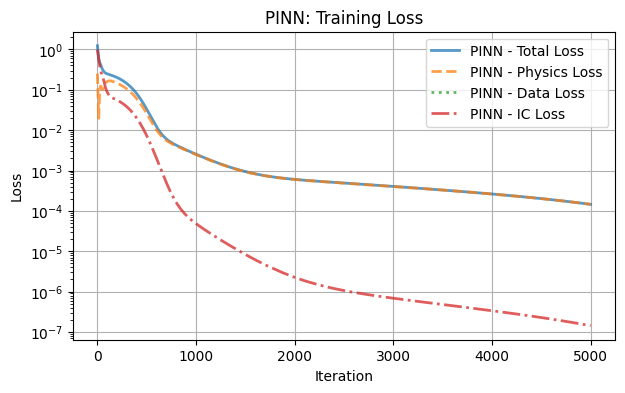

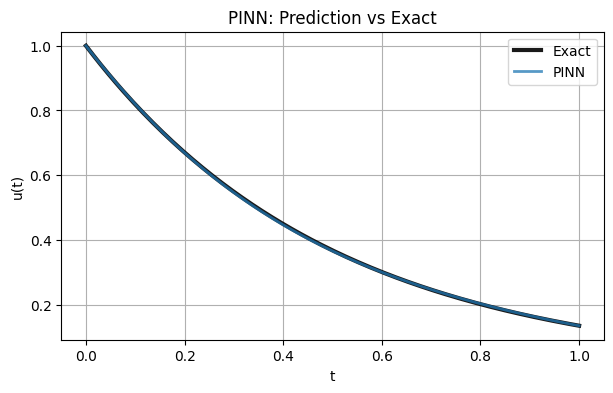

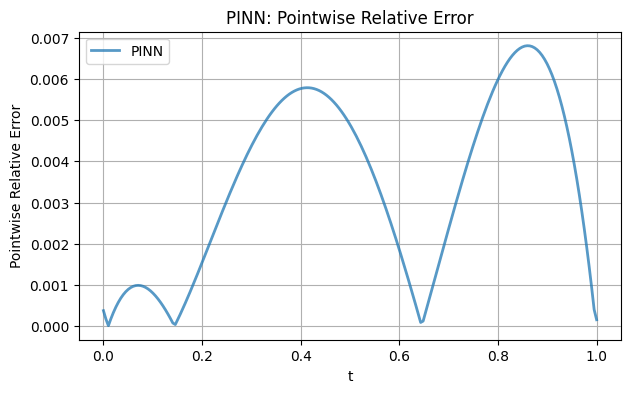

PINN Relative L2 Error: 2.876265e-03


In [29]:
default_pinn_result, default_pinn_model = load_pinn_result(PINN_DEFAULT_CONFIG)
default_pinn_eval = evaluate_pinn_model(default_pinn_model)
plot_training_pinn_loss_comparison(
    {"PINN": default_pinn_result},
    title="PINN: Training Loss"
)
plot_prediction_vs_exact(
    {"PINN": default_pinn_eval},
    title="PINN: Prediction vs Exact"
)
plot_pointwise_relative_error(
    {"PINN": default_pinn_eval},
    title="PINN: Pointwise Relative Error"
)
print(f"PINN Relative L2 Error: {default_pinn_eval['relative_l2']:.6e}")

### 2. Evaluate interpolation / extrapolation performance

Evaluate the trained PINN on three scenarios: interpolation on given samples, interpolation on unseen samples in the same domain, and extrapolation on a new domain. Plot the prediction, exact solution, pointwise relative error, and report the relative $L_2$ error.

Interpolation on given samples - Relative L2: None
Interpolation on unseen samples - Relative L2: 0.0028762652073055506
Extrapolation on [1,2] - Relative L2: 0.39721664786338806


/tmp/ipykernel_712/3645205494.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


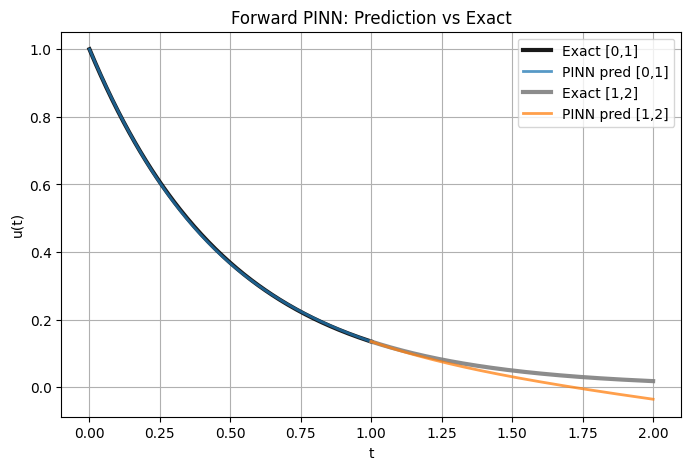

In [31]:
_, pinn_model = load_pinn_result(PINN_DEFAULT_CONFIG)

# interpolation on given samples
if PINN_DEFAULT_CONFIG["train_size"] > 0:
    t_given, u_given = generate_train_data(
        n_train=PINN_DEFAULT_CONFIG["train_size"],
        a=A_TRUE,
        seed=PINN_DEFAULT_CONFIG["seed"]
    )
    with torch.no_grad():
        u_given_pred = pinn_model(t_given.to(device))
    rel_l2_given = relative_l2_error(u_given_pred, u_given.to(device))
    pw_given = pointwise_relative_error(u_given_pred, u_given.to(device)).cpu().numpy()
else:
    t_given, u_given, rel_l2_given, pw_given = None, None, None, None

# interpolation on unseen samples
interp_out = evaluate_pinn_model(pinn_model, t_min=0.0, t_max=1.0, n_eval=200)

# extrapolation
extra_out = evaluate_pinn_model(pinn_model, t_min=1.0, t_max=2.0, n_eval=200)

print("Interpolation on given samples - Relative L2:", rel_l2_given)
print("Interpolation on unseen samples - Relative L2:", interp_out["relative_l2"])
print("Extrapolation on [1,2] - Relative L2:", extra_out["relative_l2"])

# prediction vs exact
plt.figure(figsize=(8, 5))

plt.plot(interp_out["t"], interp_out["u_exact"], color="black", linewidth=3.0, alpha=0.9, label="Exact [0,1]")
plt.plot(interp_out["t"], interp_out["u_pred"], linewidth=2.0, alpha=0.75, label="PINN pred [0,1]")

plt.plot(extra_out["t"], extra_out["u_exact"], color="gray", linewidth=3.0, alpha=0.9, label="Exact [1,2]")
plt.plot(extra_out["t"], extra_out["u_pred"], linewidth=2.0, alpha=0.75, label="PINN pred [1,2]")

if t_given is not None:
    plt.scatter(t_given.numpy(), u_given.numpy(), color="red", s=35, alpha=0.8, label="Given samples")

plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Forward PINN: Prediction vs Exact")
plt.legend()
plt.grid(True)
plt.show()

### 3. Effect of the number of collocation points

Investigate how the number of collocation points affects the final prediction accuracy. Train the PINN with $N_c = 10, 20, 50, 100 ,200$  and compare the relative $L_2$ errors.

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol10_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol50_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol100_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol200_it5000_seed0
Setting              Relative L2 Error   
----------------------------------------
Nc=10                7.409337e-03        
Nc=20                5.075523e-03        
Nc=50                3.562996e-03        
Nc=100               2.876265e-03        
Nc=200               2.801837e-03        


/tmp/ipykernel_712/3645205494.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


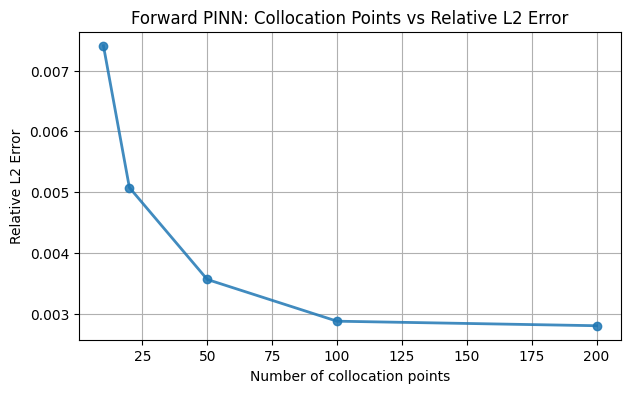

In [33]:
collocation_list = [10, 20, 50, 100, 200]

collocation_results = {}
collocation_rel_l2 = {}

for n_col in collocation_list:
    config = PINN_DEFAULT_CONFIG.copy()
    config["n_collocation"] = n_col

    train_single_pinn_run(config)
    _, model = load_pinn_result(config)
    eval_out = evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200)

    label = f"Nc={n_col}"
    collocation_results[label] = config
    collocation_rel_l2[label] = eval_out["relative_l2"]

print(f"{'Setting':<20} {'Relative L2 Error':<20}")
print("-" * 40)
for label, val in collocation_rel_l2.items():
    print(f"{label:<20} {val:<20.6e}")

plt.figure(figsize=(7, 4))
plt.plot(
    [int(k.split("=")[1]) for k in collocation_rel_l2.keys()],
    list(collocation_rel_l2.values()),
    marker="o",
    linewidth=2.0,
    alpha=0.85
)
plt.xlabel("Number of collocation points")
plt.ylabel("Relative L2 Error")
plt.title("Forward PINN: Collocation Points vs Relative L2 Error")
plt.grid(True)
plt.show()

### 4.Effect of Observed Data

Investigate how adding observed data affects the forward PINN. Train the model with $N_{data}=0,5,10$ and compare the relative $L_2$ errors.

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata5_ncol20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata10_ncol20_it5000_seed0
Setting              Relative L2 Error   
----------------------------------------
Ndata=0              5.075523e-03        
Ndata=5              5.214378e-03        
Ndata=10             5.157174e-03        


/tmp/ipykernel_712/3645205494.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


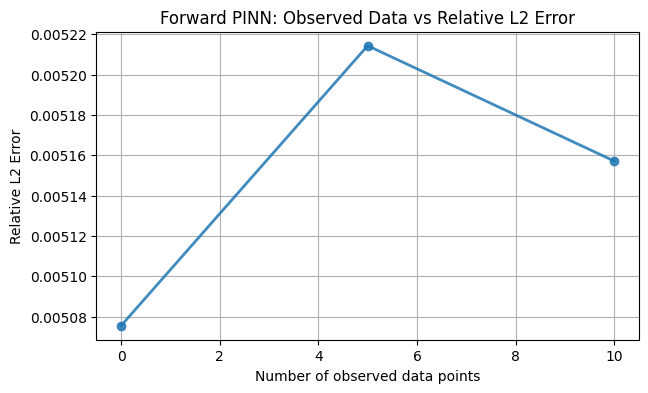

In [35]:
ndata_list = [0, 5, 10]

ndata_rel_l2 = {}

for n_data in ndata_list:
    config = PINN_DEFAULT_CONFIG.copy()
    config["train_size"] = n_data
    config["n_collocation"] = 20

    train_single_pinn_run(config)
    _, model = load_pinn_result(config)
    eval_out = evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200)

    label = f"Ndata={n_data}"
    ndata_rel_l2[label] = eval_out["relative_l2"]

print(f"{'Setting':<20} {'Relative L2 Error':<20}")
print("-" * 40)
for label, val in ndata_rel_l2.items():
    print(f"{label:<20} {val:<20.6e}")

plt.figure(figsize=(7, 4))
plt.plot(
    [int(k.split("=")[1]) for k in ndata_rel_l2.keys()],
    list(ndata_rel_l2.values()),
    marker="o",
    linewidth=2.0,
    alpha=0.85
)
plt.xlabel("Number of observed data points")
plt.ylabel("Relative L2 Error")
plt.title("Forward PINN: Observed Data vs Relative L2 Error")
plt.grid(True)
plt.show()

## appendix



[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol20_it5000_seed0


/tmp/ipykernel_712/563621545.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_712/36452

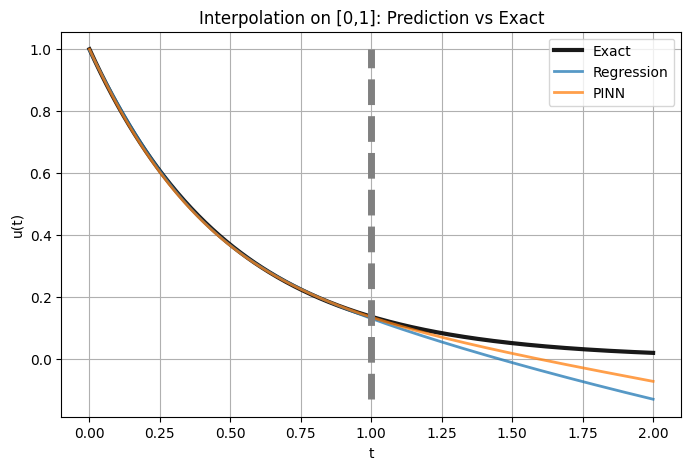

Setting                        Relative L2 Error   
-------------------------------------------------------
Regression (Interpolation)     5.291078e-03        
PINN (Interpolation)           5.075523e-03        
Regression (Extrapolation)     1.198444e+00        
PINN (Extrapolation)           6.927197e-01        


In [51]:
# ============================================================
# Regression model loader
# ============================================================
def load_regression_result(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model


# ============================================================
# Evaluate any model on a given domain
# ============================================================
def evaluate_any_model(model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u_exact = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

    with torch.no_grad():
        u_pred = model(t_tensor)

    rel_l2 = relative_l2_error(u_pred, u_exact_tensor)
    pw_rel = pointwise_relative_error(u_pred, u_exact_tensor).detach().cpu().numpy()

    return {
        "t": t,
        "u_exact": u_exact,
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

# ============================================================
# Choose the regression configuration to compare
# ============================================================
REG_COMPARE_CONFIG = DEFAULT_CONFIG.copy()
REG_COMPARE_CONFIG["optimizer"] = "Adam"
REG_COMPARE_CONFIG["lr"] = 1e-3
REG_COMPARE_CONFIG["hidden_dim"] = 32
REG_COMPARE_CONFIG["depth"] = 1
REG_COMPARE_CONFIG["activation"] = "tanh"
REG_COMPARE_CONFIG["train_size"] = 20
REG_COMPARE_CONFIG["k_fold"] = 1
REG_COMPARE_CONFIG["n_iters"] = 5000
REG_COMPARE_CONFIG["seed"] = 0

# ============================================================
# Choose the PINN configuration to compare
# ============================================================
PINN_COMPARE_CONFIG = PINN_DEFAULT_CONFIG.copy()
PINN_COMPARE_CONFIG["optimizer"] = "Adam"
PINN_COMPARE_CONFIG["lr"] = 1e-3
PINN_COMPARE_CONFIG["hidden_dim"] = 32
PINN_COMPARE_CONFIG["depth"] = 1
PINN_COMPARE_CONFIG["activation"] = "tanh"
PINN_COMPARE_CONFIG["train_size"] = 0        # default PINN setting
PINN_COMPARE_CONFIG["n_collocation"] = 20
PINN_COMPARE_CONFIG["n_iters"] = 5000
PINN_COMPARE_CONFIG["seed"] = 0

# If needed, train first
train_single_run(REG_COMPARE_CONFIG)
train_single_pinn_run(PINN_COMPARE_CONFIG)

# Load trained models
_, reg_model = load_regression_result(REG_COMPARE_CONFIG)
_, pinn_model = load_pinn_result(PINN_COMPARE_CONFIG)

# ============================================================
# Interpolation domain: [0,1]
# ============================================================
reg_interp = evaluate_any_model(reg_model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE)
pinn_interp = evaluate_any_model(pinn_model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE)

# # ============================================================
# # Extrapolation domain: [1,2]
# # ============================================================
reg_extra = evaluate_any_model(reg_model, t_min=1.0, t_max=2.0, n_eval=200, a=A_TRUE)
pinn_extra = evaluate_any_model(pinn_model, t_min=1.0, t_max=2.0, n_eval=200, a=A_TRUE)


reg_pred = evaluate_any_model(reg_model, t_min=0.0, t_max=2.0, n_eval=400, a=A_TRUE)
pinn_pred = evaluate_any_model(pinn_model, t_min=0.0, t_max=2.0, n_eval=400, a=A_TRUE)
plt.figure(figsize=(8, 5))
plt.plot(
    reg_pred["t"], reg_pred["u_exact"],
    color="black", linewidth=3.0, alpha=0.9, label="Exact"
)
plt.plot(
    reg_pred["t"], reg_pred["u_pred"],
    linewidth=2.0, alpha=0.75, label="Regression"
)
plt.plot(
    pinn_pred["t"], pinn_pred["u_pred"],
    linewidth=2.0, alpha=0.75, label="PINN"
)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.vlines(x=1.0, ymin=reg_pred["u_pred"].min(), ymax=1.0,color="gray", linestyle="--", alpha=1, linewidth=5)
plt.title("Interpolation on [0,1]: Prediction vs Exact")
plt.legend()
plt.grid(True)
plt.show()

comparison_table = {
    "Regression (Interpolation)": reg_interp["relative_l2"],
    "PINN (Interpolation)": pinn_interp["relative_l2"],
    "Regression (Extrapolation)": reg_extra["relative_l2"],
    "PINN (Extrapolation)": pinn_extra["relative_l2"],
}

print(f"{'Setting':<30} {'Relative L2 Error':<20}")
print("-" * 55)
for key, value in comparison_table.items():
    print(f"{key:<30} {value:<20.6e}")